In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Linear Model

Simplifying complex patterns into a straight “line of best fit”.

For example, suppose that height was the only determinant of body weight. If we were to plot height (the independent or ‘predictor’ variable) as a function of body weight (the dependent or ‘outcome’ variable), we might see a very linear relationship, as illustrated below.

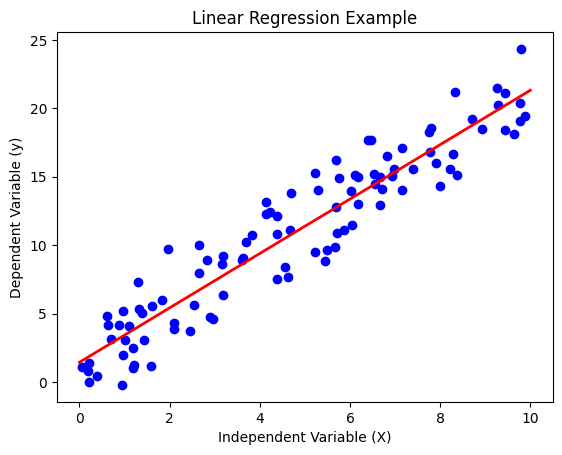

In [ ]:
# Create some data
np.random.seed(0)
X = np.random.rand(100, 1) * 10  # Independent variable (hours studied)
y = 2 * X + 1 + np.random.randn(100, 1) * 2  # Dependent variable (test scores)

# Create a linear regression model
model = LinearRegression()

# Fit the model
model.fit(X, y)

# Make predictions
X_new = np.array([[0], [10]])
y_predict = model.predict(X_new)

# Plotting the results
plt.scatter(X, y, color='blue')  # plot the data points
plt.plot(X_new, y_predict, color='red', linewidth=2)  # plot the regression line
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (y)')
plt.title('Linear Regression Example')
plt.show()

# Logistic Regression

Predicting yes/no outcomes, like if a fruit is ripe or not. (what we will use today !)

It predicts the probability of occurrence of an event by fitting data to a logistic curve. It is widely used for classification problems where the outcomes are discrete (e.g., yes/no, 0/1).

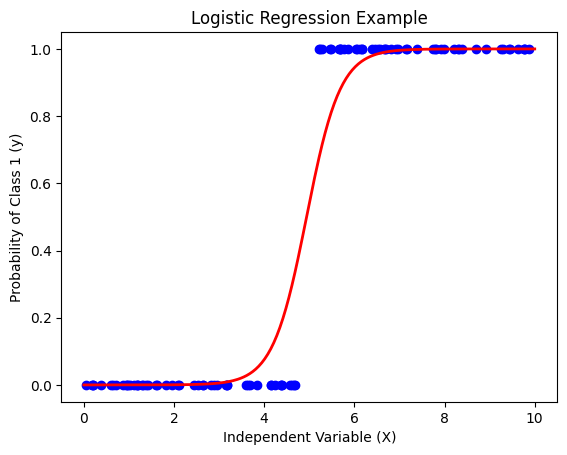

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Create some data
np.random.seed(0)
X = np.random.rand(100, 1) * 10  # Independent variable (e.g., hours studied)
y = (X > 5).astype(np.float64).ravel()  # Dependent variable (e.g., pass/fail)

# Create a logistic regression model
model = LogisticRegression()

# Fit the model
model.fit(X, y)

# Make predictions
X_test = np.linspace(0, 10, 300)
y_prob = model.predict_proba(X_test.reshape(-1, 1))[:, 1]

# Plotting the results
plt.scatter(X, y, color='blue')  # plot the data points
plt.plot(X_test, y_prob, color='red', linewidth=2)  # plot the logistic regression curve
plt.xlabel('Independent Variable (X)')
plt.ylabel('Probability of Class 1 (y)')
plt.title('Logistic Regression Example')
plt.show()

# Support Vector Machines

Separating different types of fruits using the best hyperplane.

What’s an hyperplane ? In the context of SVMs, a hyperplane is a decision boundary that separates different classes in the feature space. In a two-dimensional space, this hyperplane is a line, but in higher-dimensional spaces, it becomes a multidimensional surface.
The hyperplane’s role is crucial as it defines how the data points (observations) are classified. The position and orientation of the hyperplane are determined in a way that maximizes the separation between different classes.
The margin is the distance between the hyperplane and the nearest data point from either class. SVM aims to maximize this margin. Support vectors are the data points that lie closest to the hyperplane and are used in determining the margin and decision boundary.

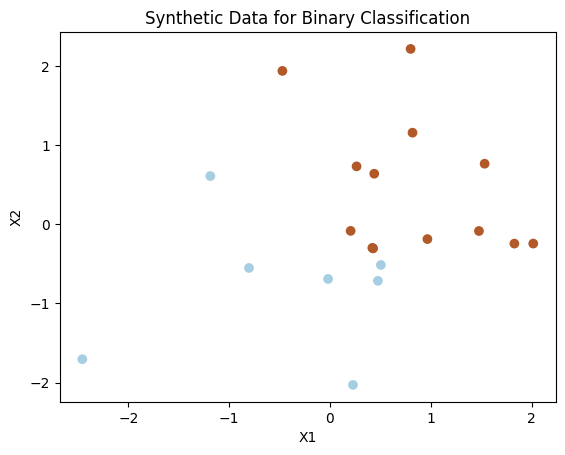

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create random data
# np.random.seed(0)
X = np.random.randn(20, 2)
Y = np.where(X[:, 0] + X[:, 1] > 0, 1, -1)

# Visualize the data
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Data for Binary Classification")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

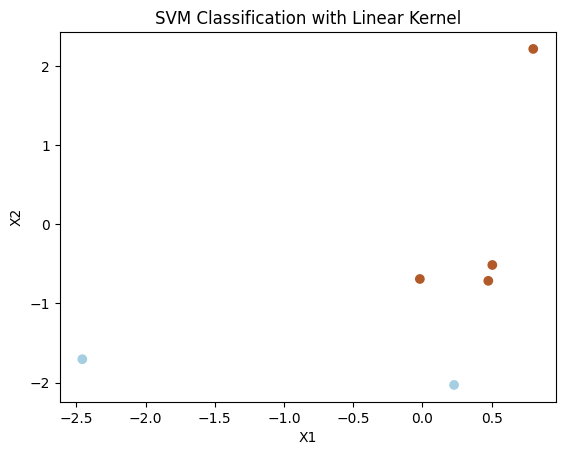

In [ ]:
# Create an SVM classifier with a linear kernel
from sklearn import svm
clf = svm.SVC(kernel='linear')

# Train the classifier on the training data
clf.fit(X_train, Y_train)

# Make predictions
Y_pred = clf.predict(X_test)
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_pred, cmap=plt.cm.Paired)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM Classification with Linear Kernel")
plt.show()

# K-Nearest Neighbours

 Identifying a fruit type based on its similarity to known fruits.

The KNN Process with Fruits :

* Think of each feature (color, size, sweetness) as a dimension in space. So, you have a multi-dimensional space where each fruit in your basket is a point in this space.
* Choosing ‘K’ - The Number of Neighbors: You decide to consider the characteristics of the ‘K’ fruits that are most similar to the unknown fruit. Let’s say you choose ‘K’ to be 3 for simplicity.
* Finding the Nearest Neighbors: You measure the distance (similarity) of all fruits in your basket to the unknown fruit. Suppose you use color and size as your measuring criteria (like using a ruler in this fruit space). You find the 3 fruits that are most similar to your unknown fruit. Let’s say these are two apples and one banana.
* Classifying the Unknown Fruit: Since the majority of the 3 closest fruits (2 out of 3) are apples, you classify the unknown fruit as an apple.
* Understanding the Intuition: The core idea is that similar things are often close to each other. In the case of fruits, if most fruits similar to the unknown one are apples, it’s likely that the unknown fruit is also an apple.
* Adjusting ‘K’ and Features: If you chose a different ‘K’, say 5, you might end up with 3 apples and 2 bananas in the nearest neighbors, which could still result in classifying the fruit as an apple. Similarly, including more features like sweetness or texture could change which fruits are nearest.
KNN assumes that things with similar characteristics (in this case, fruits with similar color, size, etc.) are likely to be of the same type. It’s a method based on the assumption that similar things exist in close proximity, i.e., “birds of a feather flock together.”

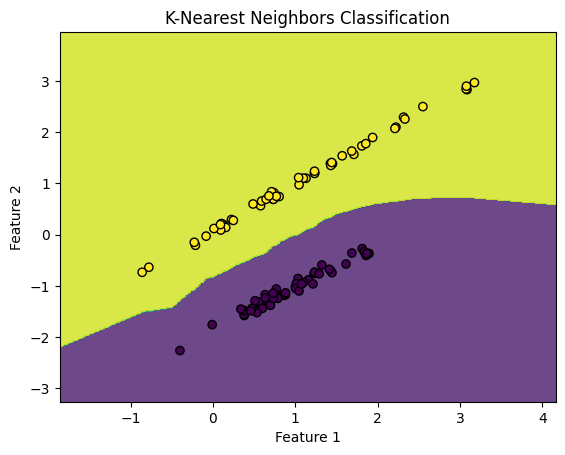

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate a random binary classification problem.
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

# Create a KNN classifier model
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model
knn.fit(X, y)

# We create a mesh of points to visualize the decision boundaries of the KNN classifier
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                 np.arange(y_min, y_max, 0.02))

# Predict class for each point in the mesh
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting the results
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Nearest Neighbors Classification')
plt.show()

# Naïve Bayes

Like guessing the type of fruit by considering the likelihood of each feature.

The main idea behind Naive Bayes is to compute the posterior probability of each class for a given set of features and select the class with the highest probability as the predicted class.
In the context of fruit classification, Naive Bayes would calculate the probability of a fruit being, say, an apple or an orange based on features like color, size, and texture, and then classify it as the type of fruit with the highest calculated probability.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Sample data
# Features: weight (grams), color (0 = Green, 1 = Yellow, 2 = Red)
# Target: types of fruits
features = np.array([[150, 0], [170, 0], [140, 2], [130, 2], [200, 1], [180, 1]])
labels = np.array(["Apple", "Apple", "Cherry", "Cherry", "Banana", "Banana"])

# don't bother for this step, it is just used to encode string labels to integers
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Creating and training the Naive Bayes model
model = GaussianNB()
model.fit(features, labels_encoded)

# Making predictions
# Let's predict the fruit type for a 160g green fruit and a 190g yellow fruit
predicted = model.predict([[160, 0], [190, 1]])
predicted_labels = label_encoder.inverse_transform(predicted)

print(f"Predictions: {predicted_labels}")

Predictions: ['Apple' 'Banana']


# Decision Tree Classification

 Breaking down decisions step-by-step, like choosing the best fruit.

It is a non-linear model that makes decisions by recursively splitting the data into subsets based on the values of input features.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the classifier on the training data
dt_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = dt_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

Accuracy: 1.0


# Random Forest Classification

 Using many decision trees to improve accuracy in fruit classification.

Random Forest Classification is a machine learning algorithm that builds multiple decision trees and merges them together to get a more accurate and stable prediction.
Let’s consider a simple example using the famous Iris dataset, which is a classification problem aiming to predict the species of iris flowers based on their features (sepal length, sepal width, petal length, and petal width)

In [ ]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Random Forest Classifier with 100 trees
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier on the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


# So, which model should I pick for my problem ?
Choosing the right model for your machine learning problem depends on several factors, including the nature of your data, the specific requirements of the task, and the computational resources available. Here are some general guidelines to help you decide:

Nature of the Problem:

* For binary classification problems, Logistic Regression or Support Vector Machines could be a good starting point.
* For multi-class classification, you might consider Random Forests, Naive Bayes, or K-Nearest Neighbors.
* If you have a regression problem, starting with Linear Regression is typically a good idea.

Data Characteristics:

* If your data is linearly separable, Linear Models (like Linear or Logistic Regression) are effective.
* For complex, non-linear relationships, consider Random Forests, Kernel SVM, or Neural Networks.
* If your dataset is small, simpler models like Naive Bayes or K-Nearest Neighbors might work well.

Accuracy vs Interpretability:

* If you need a model that is easy to interpret, go for Linear Models or Decision Trees.
* For higher accuracy at the cost of interpretability, Ensemble Methods (like Random Forests) or Deep Learning Models are suitable.

Training Time and Computational Resources:

* If you have limited computational resources, simpler models like Naive Bayes or Linear Regression are more computationally efficient.
* For large datasets or more complex problems, you might need more powerful models like Random Forests or Deep Learning Models, which require more computational power and time to train.

Handling of Overfitting:

* Models like Decision Trees can easily overfit on the training data. In such cases, using an ensemble method like Random Forest can help.
* Regularization techniques are effective with Linear Models to prevent overfitting.

Feature Scaling Requirements:

* Models like K-Nearest Neighbors and Support Vector Machines require feature scaling for optimal performance.
* Models like Decision Trees and Random Forests do not require feature scaling.

Experimentation:

* Often, the best way to find the most suitable model is through experimentation. Try different models, compare their performance using cross-validation, and consider tuning their hyperparameters.